# Boosting Model (XGBoost) — KPI Analysis

This notebook analyses the forecasting performance of the **XGBoost (Boosting) model** on Japan (Tohoku region) electricity spot prices.

> **Note:** XGBoost forecast data is available from **Feb 2026** onwards. Earlier periods contain only LSTM data.

**KPIs analysed:**
- **MAE** – Mean Absolute Error (average magnitude of error)
- **RMSE** – Root Mean Squared Error (penalises large errors)
- **SMAPE** – Symmetric Mean Absolute Percentage Error (%)

**Data period:** 2026-02-01 → 2026-02-28

## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

XGB_COLOR    = '#d62728'
ACTUAL_COLOR = '#2ca02c'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [3]:
DATA_PATH = "KPI/boosting"

daily_kpis      = pd.read_csv(f"{DATA_PATH}/daily_kpis.csv", parse_dates=["date"])
monthly_kpis    = pd.read_csv(f"{DATA_PATH}/monthly_kpis.csv")
actual_forecast = pd.read_csv(f"{DATA_PATH}/actual_forecast.csv", parse_dates=["datetime"])

# Keep only XGBoost-relevant columns from actual_forecast
af = actual_forecast[["datetime", "actual_value", "xgboost_forecast"]].copy()

# Keep only XGBoost columns in daily / monthly
xgb_daily   = daily_kpis[["date"] + [c for c in daily_kpis.columns if c.startswith("xgboost_")]].copy()
xgb_monthly = monthly_kpis[["month"] + [c for c in monthly_kpis.columns if c.startswith("xgboost_")]].copy()

print(f"Data loaded from     : {DATA_PATH}")
print(f"Raw 30-min rows      : {len(af)}")
print(f"Daily KPI rows       : {len(xgb_daily)}  "
      f"(dates: {xgb_daily['date'].min().date()} to {xgb_daily['date'].max().date()})")
print(f"Monthly KPI rows     : {len(xgb_monthly)}")
display(xgb_daily.head())

Data loaded from     : KPI/boosting
Raw 30-min rows      : 4369
Daily KPI rows       : 92  (dates: 2025-11-01 to 2026-01-31)
Monthly KPI rows     : 3


,date,xgboost_mae,xgboost_rmse,xgboost_smape
0,2025-11-01,2.536555,3.213339,23.282749
1,2025-11-02,2.375910,3.585809,28.219934
2,2025-11-03,0.662278,0.831082,6.446130
3,2025-11-04,1.373725,2.023094,14.946021
4,2025-11-05,0.673290,0.958558,6.440408


## 3. Data Overview

In [4]:
print('=== Daily KPI (First 10 rows) ===')
display(xgb_daily.head(10))

print('\n=== Monthly KPI ===')
display(xgb_monthly)

print('\n=== Descriptive Statistics — Daily KPIs ===')
display(xgb_daily[['xgboost_mae', 'xgboost_rmse', 'xgboost_smape']].describe().round(4))

=== Daily KPI (First 10 rows) ===


,date,xgboost_mae,xgboost_rmse,xgboost_smape
0,2025-11-01,2.536555,3.213339,23.282749
1,2025-11-02,2.375910,3.585809,28.219934
2,2025-11-03,0.662278,0.831082,6.446130
3,2025-11-04,1.373725,2.023094,14.946021
4,2025-11-05,0.673290,0.958558,6.440408
5,2025-11-06,2.402414,3.205198,23.361664
6,2025-11-07,1.461935,1.986854,21.210508
7,2025-11-08,0.714209,0.945207,6.967664
8,2025-11-09,1.553029,2.107333,14.571851
9,2025-11-10,NaN,NaN,NaN



=== Monthly KPI ===


,month,xgboost_mae,xgboost_rmse,xgboost_smape
0,2025-11,1.703640,2.347429,17.946344
1,2025-12,1.482631,1.846918,13.708336
2,2026-01,1.373608,2.195173,10.746868



=== Descriptive Statistics — Daily KPIs ===


,xgboost_mae,xgboost_rmse,xgboost_smape
count,79.0000,79.0000,79.0000
mean,1.5185,1.9570,14.2417
std,0.6227,0.8409,7.6925
min,0.4557,0.6173,5.0062
25%,1.0650,1.3894,8.8086
50%,1.3759,1.8758,12.9353
75%,1.9174,2.3339,17.7934
max,3.6310,5.3519,46.2809


## 4. Actual vs XGBoost Forecast — Full Period

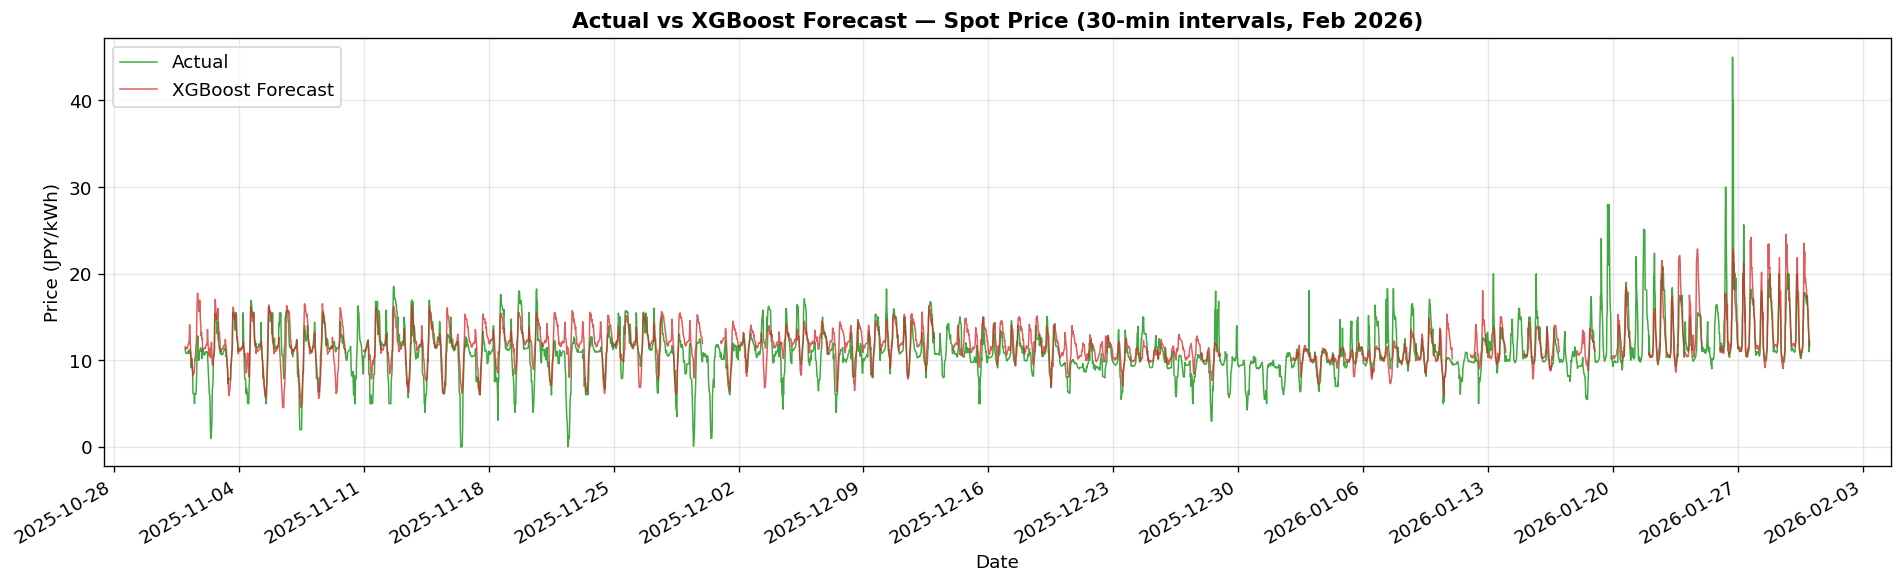

Plot saved.


In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(af['datetime'], af['actual_value'],
        label='Actual', color=ACTUAL_COLOR, linewidth=0.9, alpha=0.9)
ax.plot(af['datetime'], af['xgboost_forecast'],
        label='XGBoost Forecast', color=XGB_COLOR, linewidth=0.9, alpha=0.75)

ax.set_title('Actual vs XGBoost Forecast — Spot Price (30-min intervals, Feb 2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (JPY/kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
ax.legend()
plt.tight_layout()
plt.savefig('KPI/xgboost_actual_vs_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 5. Daily KPI Trends

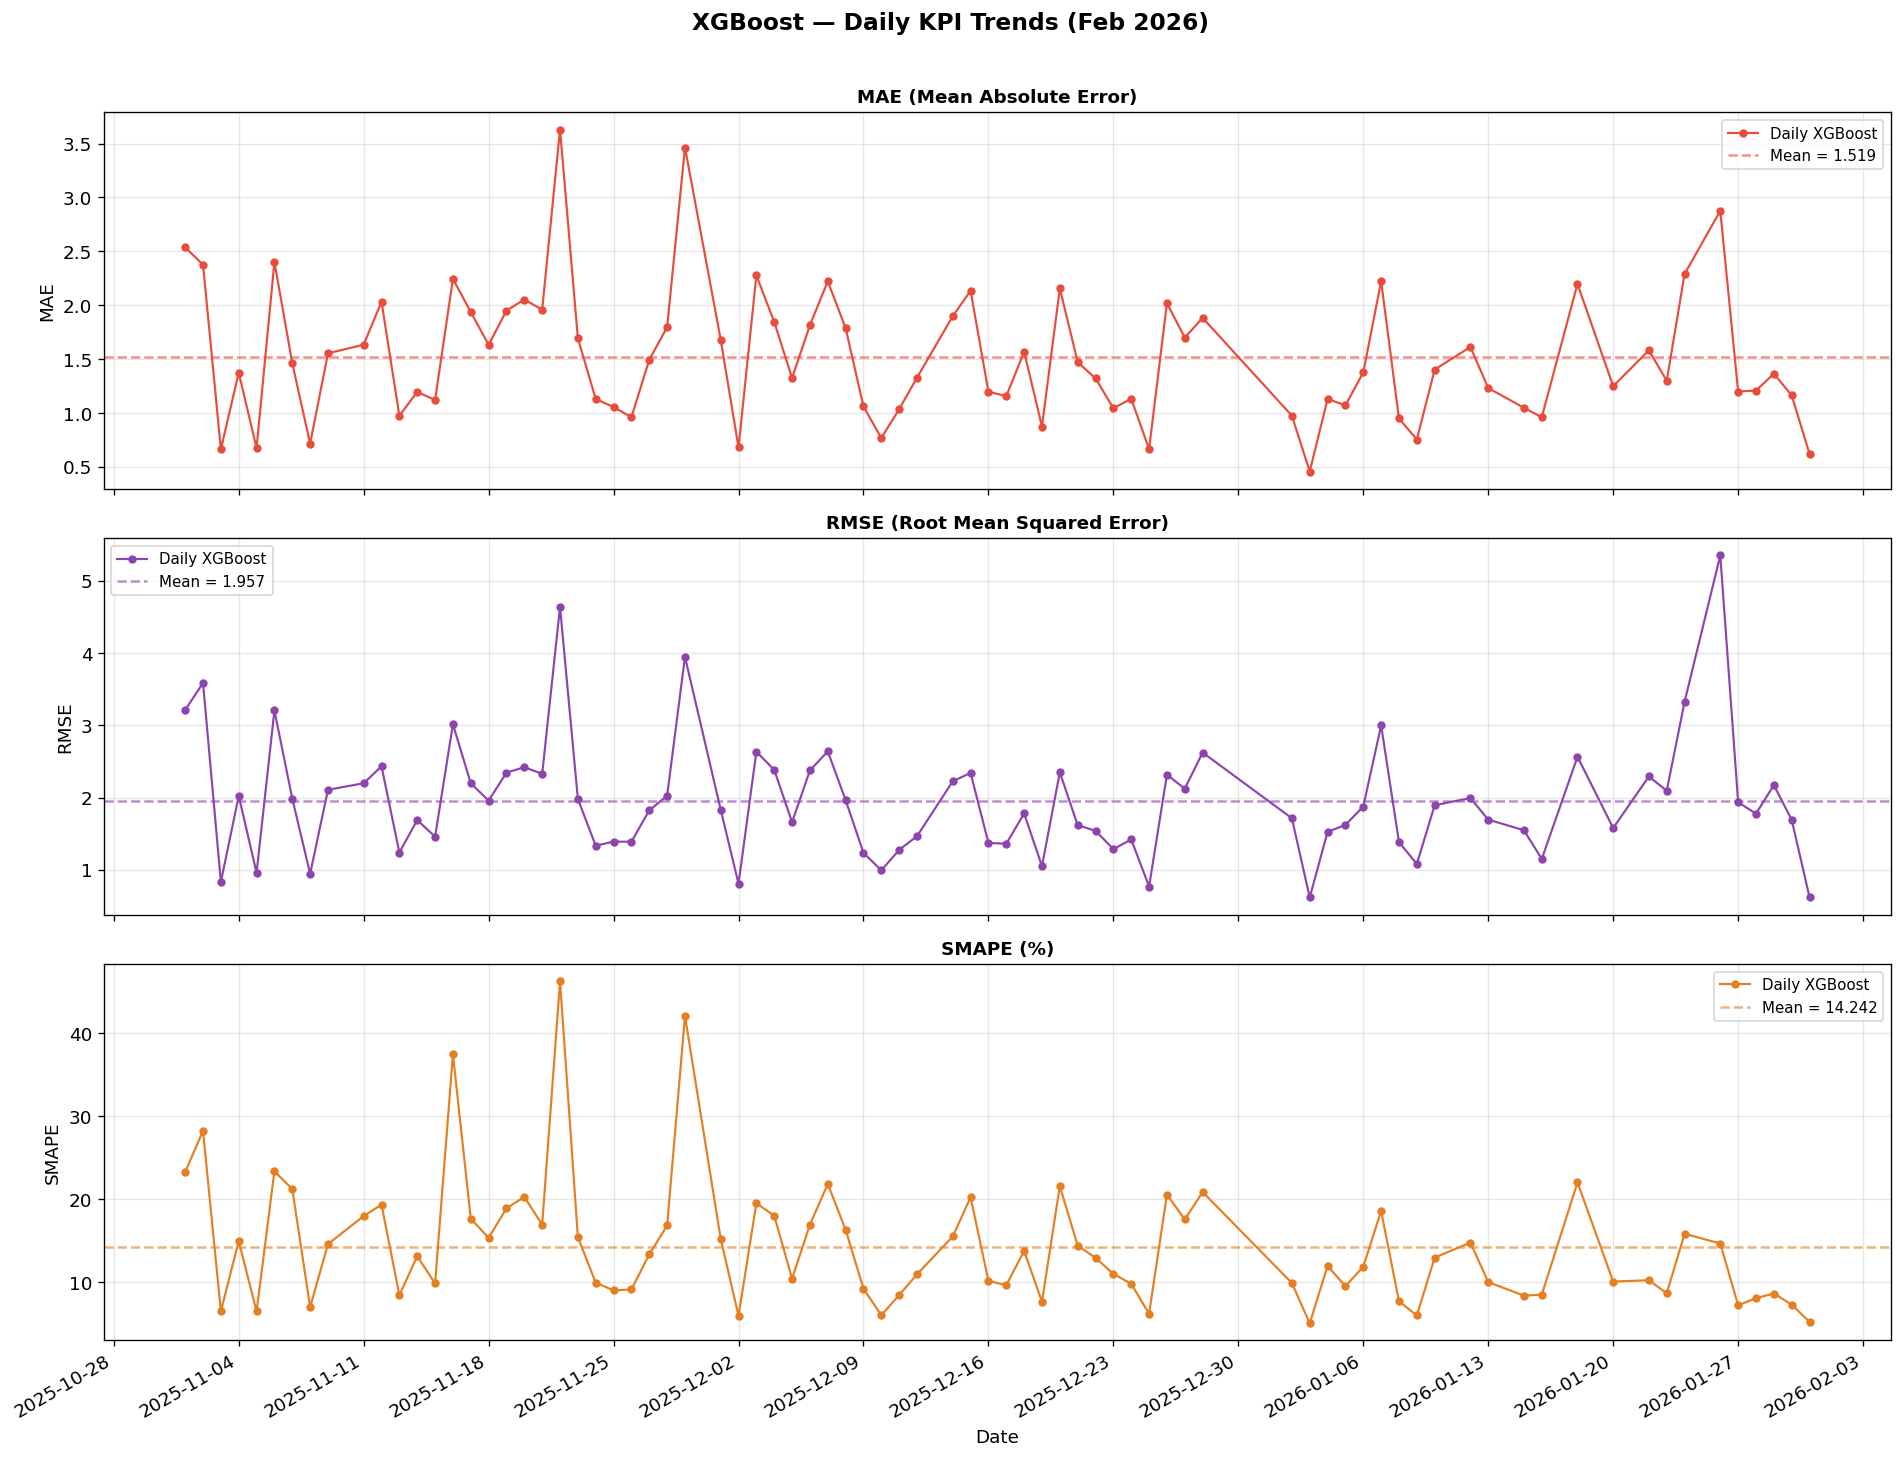

Plot saved.


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

metrics = [
    ('xgboost_mae',   'MAE (Mean Absolute Error)',        '#e74c3c'),
    ('xgboost_rmse',  'RMSE (Root Mean Squared Error)',   '#8e44ad'),
    ('xgboost_smape', 'SMAPE (%)',                        '#e67e22'),
]

for ax, (col, title, color) in zip(axes, metrics):
    valid = xgb_daily.dropna(subset=[col])
    ax.plot(valid['date'], valid[col], color=color, linewidth=1.3,
            marker='o', markersize=4, label='Daily XGBoost')
    ax.axhline(valid[col].mean(), color=color, linewidth=1.5, linestyle='--',
               alpha=0.6, label=f'Mean = {valid[col].mean():.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(col.split('_')[-1].upper())
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Date')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
fig.autofmt_xdate()
fig.suptitle('XGBoost — Daily KPI Trends (Feb 2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('KPI/xgboost_daily_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 6. Monthly KPI Summary

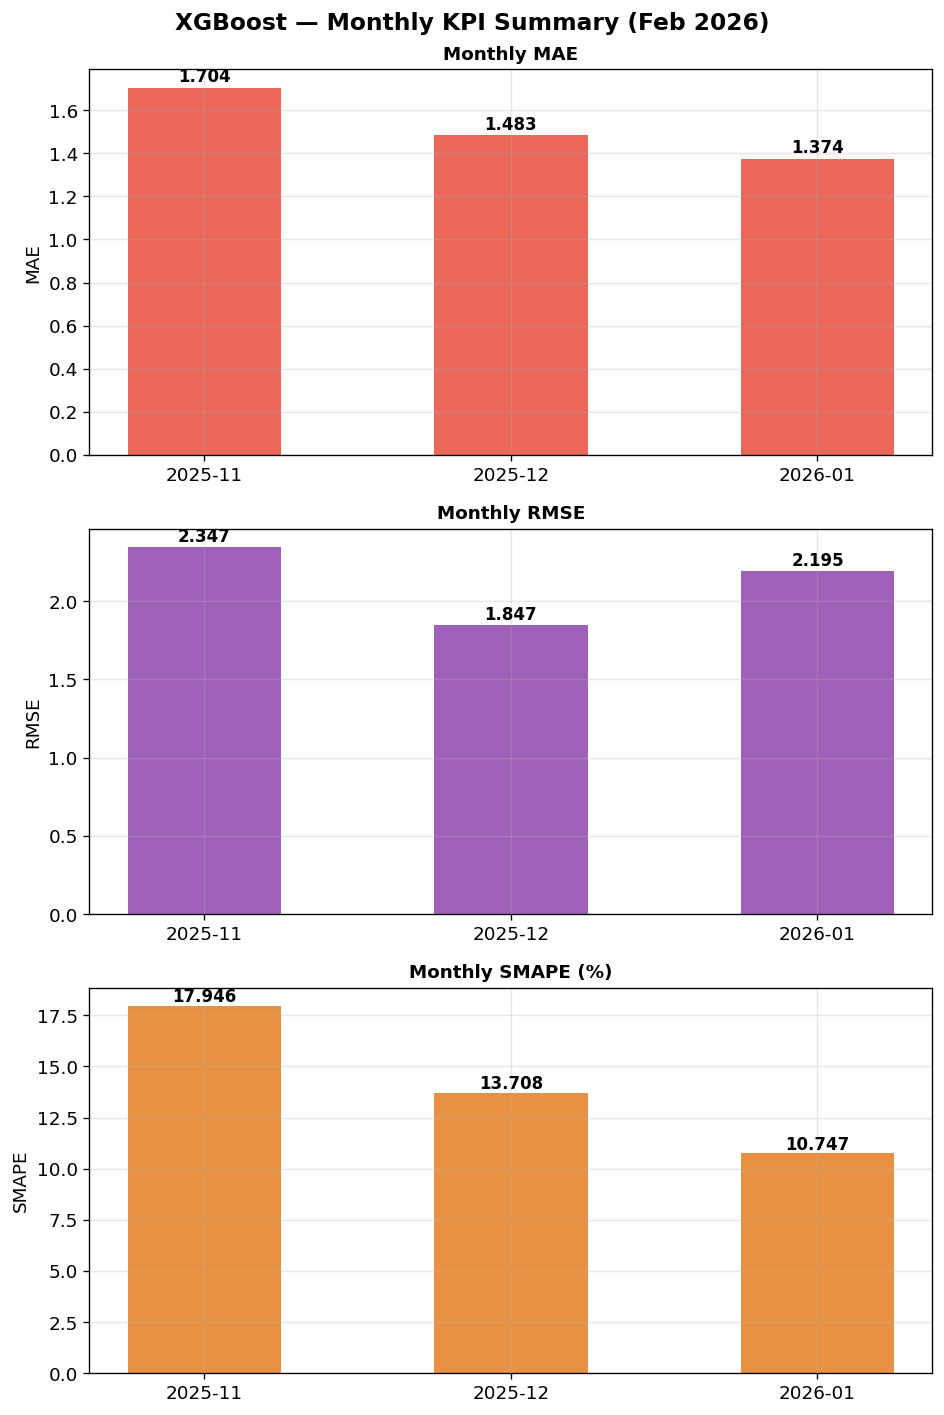

Plot saved.


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

monthly_metrics = [
    ('xgboost_mae',   'Monthly MAE',    '#e74c3c'),
    ('xgboost_rmse',  'Monthly RMSE',   '#8e44ad'),
    ('xgboost_smape', 'Monthly SMAPE (%)', '#e67e22'),
]

for ax, (col, title, color) in zip(axes, monthly_metrics):
    bars = ax.bar(xgb_monthly['month'], xgb_monthly[col], color=color, alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(col.split('_')[-1].upper())
    for bar, val in zip(bars, xgb_monthly[col]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('XGBoost — Monthly KPI Summary (Feb 2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('KPI/xgboost_monthly_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 7. Error Distribution

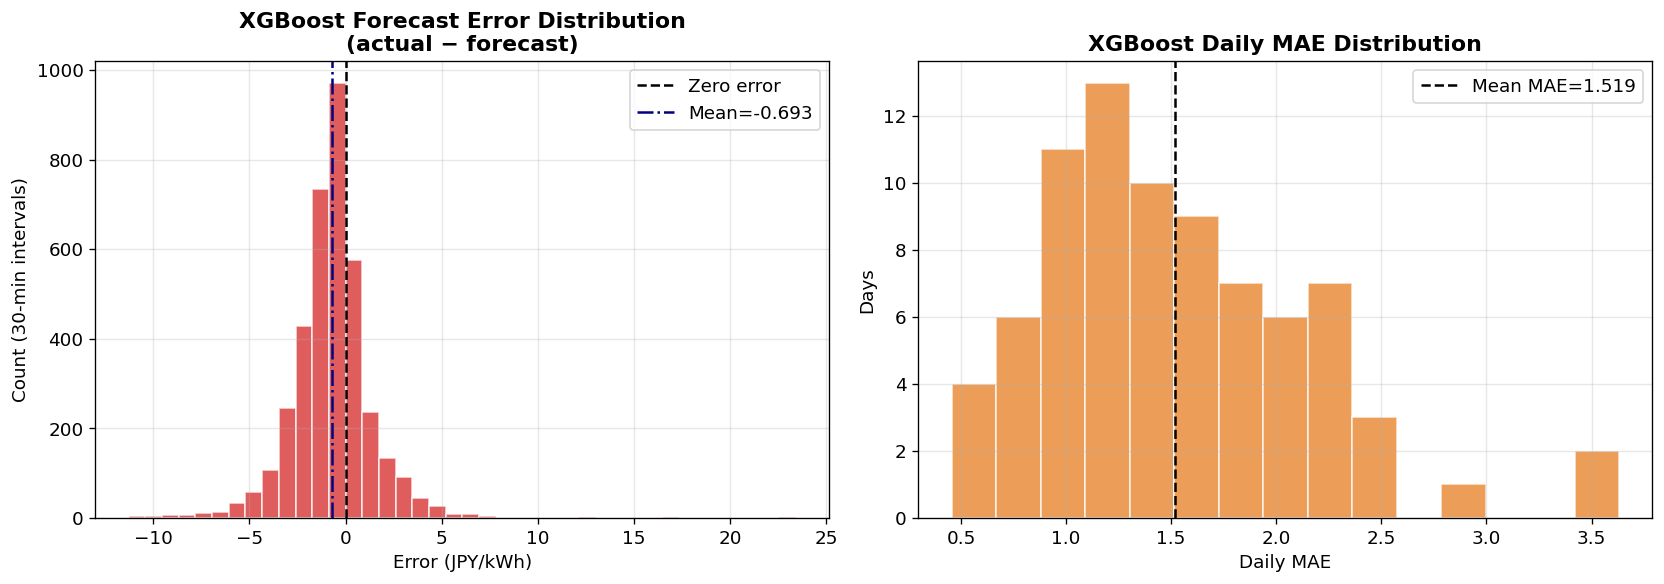

Plot saved.


In [8]:
af_valid = af.dropna(subset=['xgboost_forecast', 'actual_value']).copy()
af_valid['error'] = af_valid['actual_value'] - af_valid['xgboost_forecast']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Error histogram ───────────────────────────────────────────────────────────
axes[0].hist(af_valid['error'], bins=40, color=XGB_COLOR, alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
axes[0].axvline(af_valid['error'].mean(), color='navy', linewidth=1.5, linestyle='-.',
                label=f'Mean={af_valid["error"].mean():.3f}')
axes[0].set_title('XGBoost Forecast Error Distribution\n(actual − forecast)', fontweight='bold')
axes[0].set_xlabel('Error (JPY/kWh)')
axes[0].set_ylabel('Count (30-min intervals)')
axes[0].legend()

# ── Daily MAE distribution ────────────────────────────────────────────────────
valid_daily = xgb_daily.dropna(subset=['xgboost_mae'])
axes[1].hist(valid_daily['xgboost_mae'], bins=15, color='#e67e22', alpha=0.75, edgecolor='white')
axes[1].axvline(valid_daily['xgboost_mae'].mean(), color='black', linewidth=1.5, linestyle='--',
                label=f'Mean MAE={valid_daily["xgboost_mae"].mean():.3f}')
axes[1].set_title('XGBoost Daily MAE Distribution', fontweight='bold')
axes[1].set_xlabel('Daily MAE')
axes[1].set_ylabel('Days')
axes[1].legend()

plt.tight_layout()
plt.savefig('KPI/xgboost_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 8. Best & Worst Days

In [9]:
valid_d = xgb_daily.dropna(subset=['xgboost_mae'])

print('=== Top 10 BEST Days (Lowest MAE) ===')
display(valid_d.nsmallest(10, 'xgboost_mae')[['date', 'xgboost_mae', 'xgboost_rmse', 'xgboost_smape']].reset_index(drop=True))

print('\n=== Top 10 WORST Days (Highest MAE) ===')
display(valid_d.nlargest(10, 'xgboost_mae')[['date', 'xgboost_mae', 'xgboost_rmse', 'xgboost_smape']].reset_index(drop=True))

=== Top 10 BEST Days (Lowest MAE) ===


,date,xgboost_mae,xgboost_rmse,xgboost_smape
0,2026-01-03,0.455657,0.617330,5.006235
1,2026-01-31,0.620000,0.620000,5.175292
2,2025-11-03,0.662278,0.831082,6.446130
3,2025-12-25,0.663531,0.768803,6.162586
4,2025-11-05,0.673290,0.958558,6.440408
5,2025-12-02,0.679218,0.806939,5.914001
6,2025-11-08,0.714209,0.945207,6.967664
7,2026-01-09,0.752940,1.081184,5.961571
8,2025-12-10,0.766862,0.993403,5.983336
9,2025-12-19,0.873487,1.050633,7.616364



=== Top 10 WORST Days (Highest MAE) ===


,date,xgboost_mae,xgboost_rmse,xgboost_smape
0,2025-11-22,3.630965,4.636580,46.280940
1,2025-11-29,3.463643,3.947348,42.095873
2,2026-01-26,2.876424,5.351851,14.638838
3,2025-11-01,2.536555,3.213339,23.282749
4,2025-11-06,2.402414,3.205198,23.361664
5,2025-11-02,2.375910,3.585809,28.219934
6,2026-01-24,2.290067,3.326208,15.819887
7,2025-12-03,2.276677,2.634731,19.500315
8,2025-11-16,2.244226,3.015061,37.480279
9,2026-01-07,2.223067,2.999477,18.562668


## 9. Intra-day Error Pattern (Average by Hour)

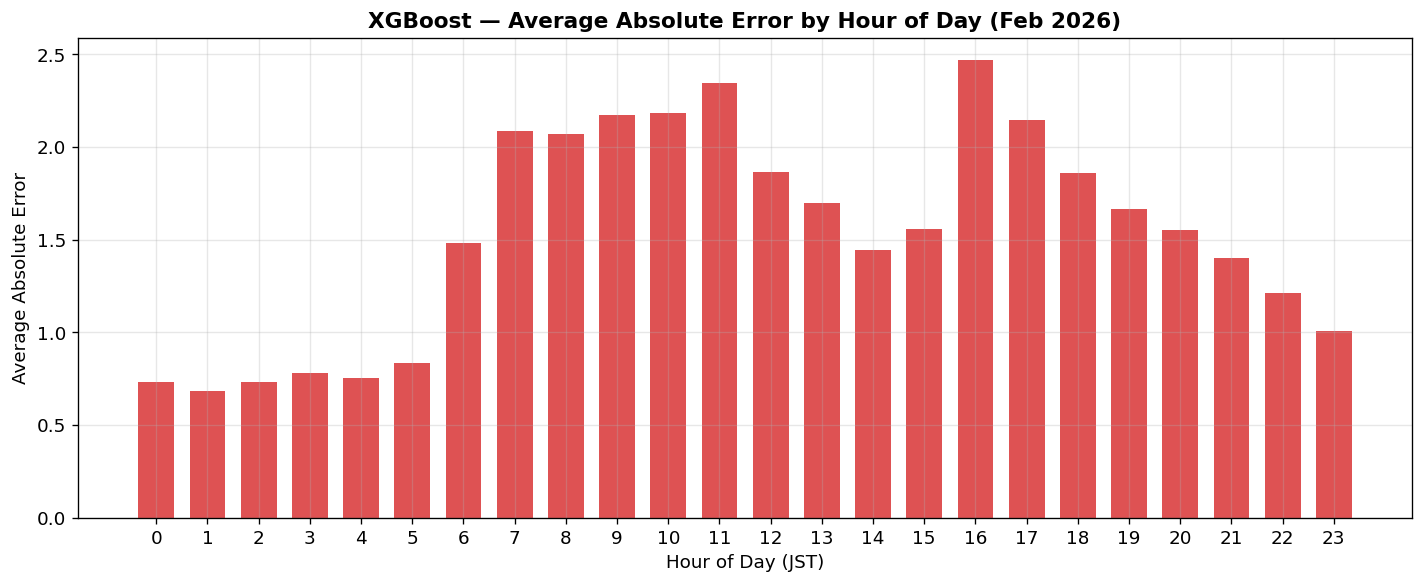

Plot saved.


In [10]:
af_valid['hour'] = af_valid['datetime'].dt.hour
af_valid['abs_error'] = af_valid['error'].abs()

hourly_mae = af_valid.groupby('hour')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_mae.index, hourly_mae.values, color=XGB_COLOR, alpha=0.8, width=0.7)
ax.set_xlabel('Hour of Day (JST)')
ax.set_ylabel('Average Absolute Error')
ax.set_title('XGBoost — Average Absolute Error by Hour of Day (Feb 2026)', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('KPI/xgboost_hourly_error.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 10. Key Insights

In [11]:
valid_d = xgb_daily.dropna(subset=['xgboost_mae'])

overall_mae   = valid_d['xgboost_mae'].mean()
overall_rmse  = valid_d['xgboost_rmse'].mean()
overall_smape = valid_d['xgboost_smape'].mean()

best_day  = valid_d.loc[valid_d['xgboost_mae'].idxmin()]
worst_day = valid_d.loc[valid_d['xgboost_mae'].idxmax()]

bias = af_valid['error'].mean()  # positive = under-forecast, negative = over-forecast

print('=' * 60)
print('  XGBOOST MODEL — KEY INSIGHTS  (Feb 2026)')
print('=' * 60)
print(f'  Average Daily MAE   : {overall_mae:.4f} JPY/kWh')
print(f'  Average Daily RMSE  : {overall_rmse:.4f} JPY/kWh')
print(f'  Average Daily SMAPE : {overall_smape:.2f}%')
print()
print(f'  Monthly MAE   : {xgb_monthly["xgboost_mae"].values[0]:.4f}')
print(f'  Monthly RMSE  : {xgb_monthly["xgboost_rmse"].values[0]:.4f}')
print(f'  Monthly SMAPE : {xgb_monthly["xgboost_smape"].values[0]:.2f}%')
print()
print(f'  Forecast Bias   : {bias:+.4f} JPY/kWh  ({"Under-forecast" if bias > 0 else "Over-forecast"})')
print(f'  Best day  (lowest MAE) : {best_day["date"].date()}  MAE={best_day["xgboost_mae"]:.4f}')
print(f'  Worst day (highest MAE): {worst_day["date"].date()}  MAE={worst_day["xgboost_mae"]:.4f}')
print(f'  Days with no XGBoost forecast : {xgb_daily["xgboost_mae"].isna().sum()}')
print('=' * 60)

  XGBOOST MODEL — KEY INSIGHTS  (Feb 2026)
  Average Daily MAE   : 1.5185 JPY/kWh
  Average Daily RMSE  : 1.9570 JPY/kWh
  Average Daily SMAPE : 14.24%

  Monthly MAE   : 1.7036
  Monthly RMSE  : 2.3474
  Monthly SMAPE : 17.95%

  Forecast Bias   : -0.6927 JPY/kWh  (Over-forecast)
  Best day  (lowest MAE) : 2026-01-03  MAE=0.4557
  Worst day (highest MAE): 2025-11-22  MAE=3.6310
  Days with no XGBoost forecast : 13
